<p align="center">
  <img src="Georgian_College_logo.svg.png" alt="Georgian College Logo" width="300">
</p>

# AIDI-1003: Final Group Project
## Cybersecurity Threat Detection - Supervised Learning
---
**Group 9** 
* **Ivan Rodriguez Cuevas** | 200652010
* **Sehdev Singh** | 200612780
* **Joao Pedro Schneidr** | 200586154

#### **Date:** April 14, 2026 <br>
#### **Professor:** Ethan Davis
---

#### Load and Explore Dataset

In [171]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, auc
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier


In [172]:
#Load dataset using pandas
df = pd.read_csv('cybersecurity.csv')

In [173]:
#Shape of dataset: number of rows and columns
print(df.shape)

(10000, 13)


In [174]:
#Statistical description of dataset
df.describe()

,src_port,dst_port,bytes_sent,bytes_received,label
count,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000
mean,27052.223700,2027.280500,1.412572e+05,2.620883e+05,0.040000
std,20978.783832,6769.141395,2.128140e+06,3.767695e+06,0.195969
min,21.000000,5.000000,1.700000e+01,3.000000e+00,0.000000
25%,6092.250000,25.000000,7.148250e+03,1.096075e+04,0.000000
50%,25431.500000,443.000000,2.181550e+04,3.747300e+04,0.000000
75%,45215.750000,1433.000000,6.509525e+04,1.213795e+05,0.000000
max,65524.000000,65491.000000,1.391704e+08,2.914830e+08,1.000000


In [175]:
#Visualize the first 5 rows of the data
df.head()

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,False,0,benign
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign


In [176]:
#Check data type of each column
print(df.dtypes)

timestamp              object
src_ip                 object
dst_ip                 object
src_port                int64
dst_port                int64
protocol               object
bytes_sent              int64
bytes_received          int64
user_agent             object
url                    object
is_internal_traffic      bool
label                   int64
attack_type            object
dtype: object


In [177]:
#Check for missing values
print(df.isnull().sum())

timestamp                 0
src_ip                    0
dst_ip                    0
src_port                  0
dst_port                  0
protocol                  0
bytes_sent                0
bytes_received            0
user_agent                0
url                    3232
is_internal_traffic       0
label                     0
attack_type               0
dtype: int64


attack_type
benign                 9600
brute-force             108
port-scan                81
sql-injection            64
xss                      34
credential-stuffing      28
ddos                     27
command-injection        26
exploit-attempt          22
c2                       10
Name: count, dtype: int64
label
0    9600
1     400
Name: count, dtype: int64


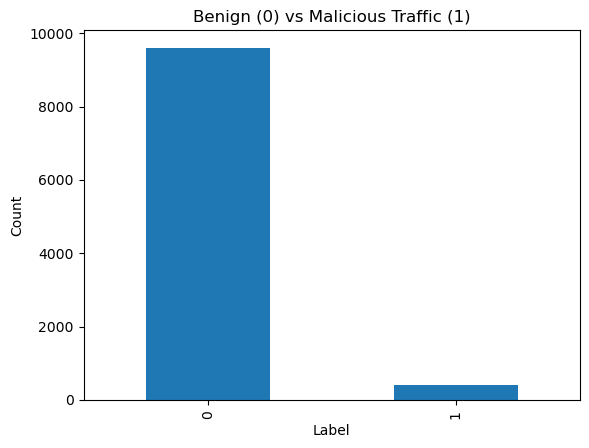

In [178]:
#Check number of attack types (multiple classes)
print(df['attack_type'].value_counts())
#Check benign vs malicious traffic (binary class)
print(df['label'].value_counts())

#Plot benign (0) vs malicious traffic (1)
df['label'].value_counts().plot(kind='bar')
plt.title("Benign (0) vs Malicious Traffic (1)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [179]:
print("\nLabel percentages: \n", df["label"].value_counts(normalize=True) * 100)


Label percentages: 
 label
0    96.0
1     4.0
Name: proportion, dtype: float64


As we can see in the above plot, we are dealing with a class imbalance.

#### Exploratory Data Analysis

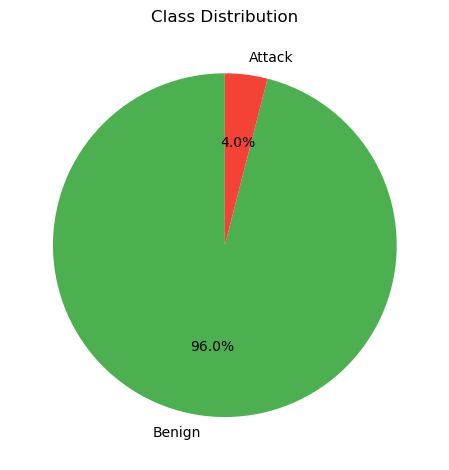

In [180]:
# Label distribution pie chart
label_counts = df['label'].value_counts()
label_counts.plot(kind='pie', labels=['Benign','Attack'], autopct='%1.1f%%',
                  colors=['#4CAF50','#F44336'], startangle=90)
plt.title('Class Distribution')
plt.ylabel('')
plt.tight_layout()
#plt.savefig('class_distribution.png', dpi=150)
plt.show()

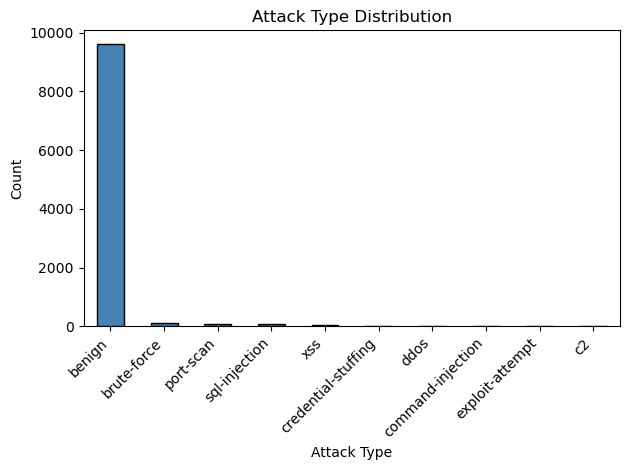

In [181]:
# Attack type distribution
attack_counts = df['attack_type'].value_counts()
attack_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Attack Type Distribution')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
#plt.savefig('attack_distribution.png', dpi=150)
plt.show()

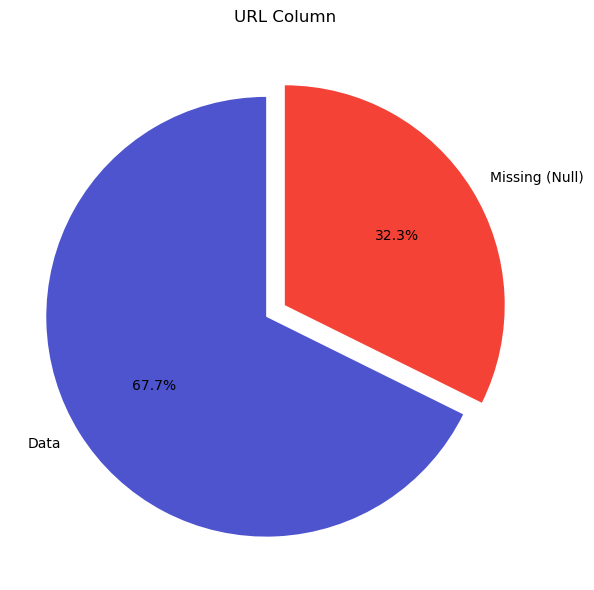

In [182]:
missing_counts = df['url'].isnull().value_counts()

labels = ['Data' if x == False else 'Missing (Null)' for x in missing_counts.index]

plt.figure(figsize=(8, 6))
missing_counts.plot(kind='pie', 
                    labels=labels, 
                    autopct='%1.1f%%',
                    colors=["#4D54CE", "#F44336"],
                    startangle=90,
                    explode=(0.1, 0) if len(missing_counts) > 1 else None)

plt.title('URL Column')
plt.ylabel('')
plt.tight_layout()
#plt.savefig('url_missing_values.png', dpi=300, transparent=True)
plt.show()

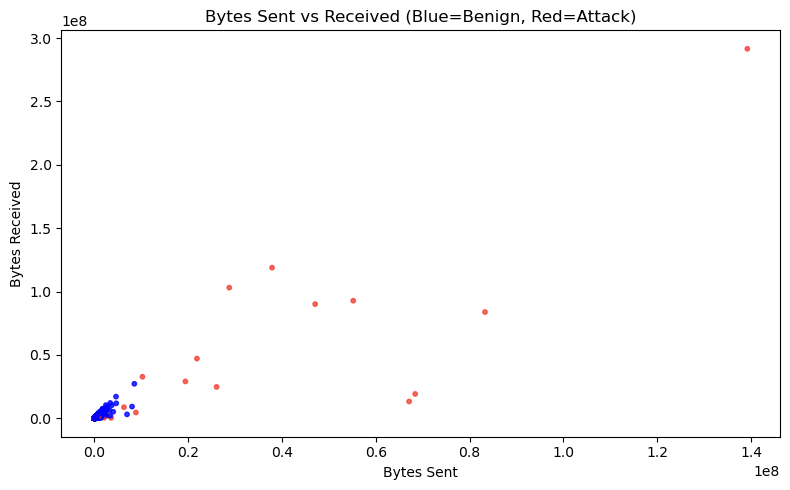

In [183]:
# Bytes sent vs received scatter
plt.figure(figsize=(8,5))
colors = df['label'].map({0:"#0004FF", 1:'#F44336'})
plt.scatter(df['bytes_sent'], df['bytes_received'], c=colors, alpha=0.8, s=10)
plt.xlabel('Bytes Sent')
plt.ylabel('Bytes Received')
plt.title('Bytes Sent vs Received (Blue=Benign, Red=Attack)')
plt.tight_layout()
#plt.savefig('bytes_scatter.png', dpi=150)
plt.show()

/var/folders/yv/z_mmg1x11x3703_nbg6q2_9w0000gn/T/ipykernel_43095/2451362734.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='bytes_sent', data=df, palette=['#4CAF50','#F44336'])


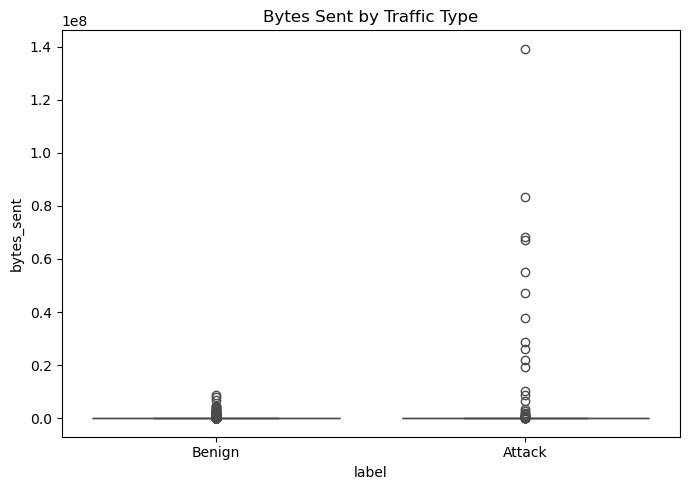

In [184]:
# Boxplot: bytes_sent by label
plt.figure(figsize=(7,5))
sns.boxplot(x='label', y='bytes_sent', data=df, palette=['#4CAF50','#F44336'])
plt.xticks([0,1], ['Benign','Attack'])
plt.title('Bytes Sent by Traffic Type')
plt.tight_layout()
#plt.savefig('boxplot_bytes.png', dpi=150)
plt.show()

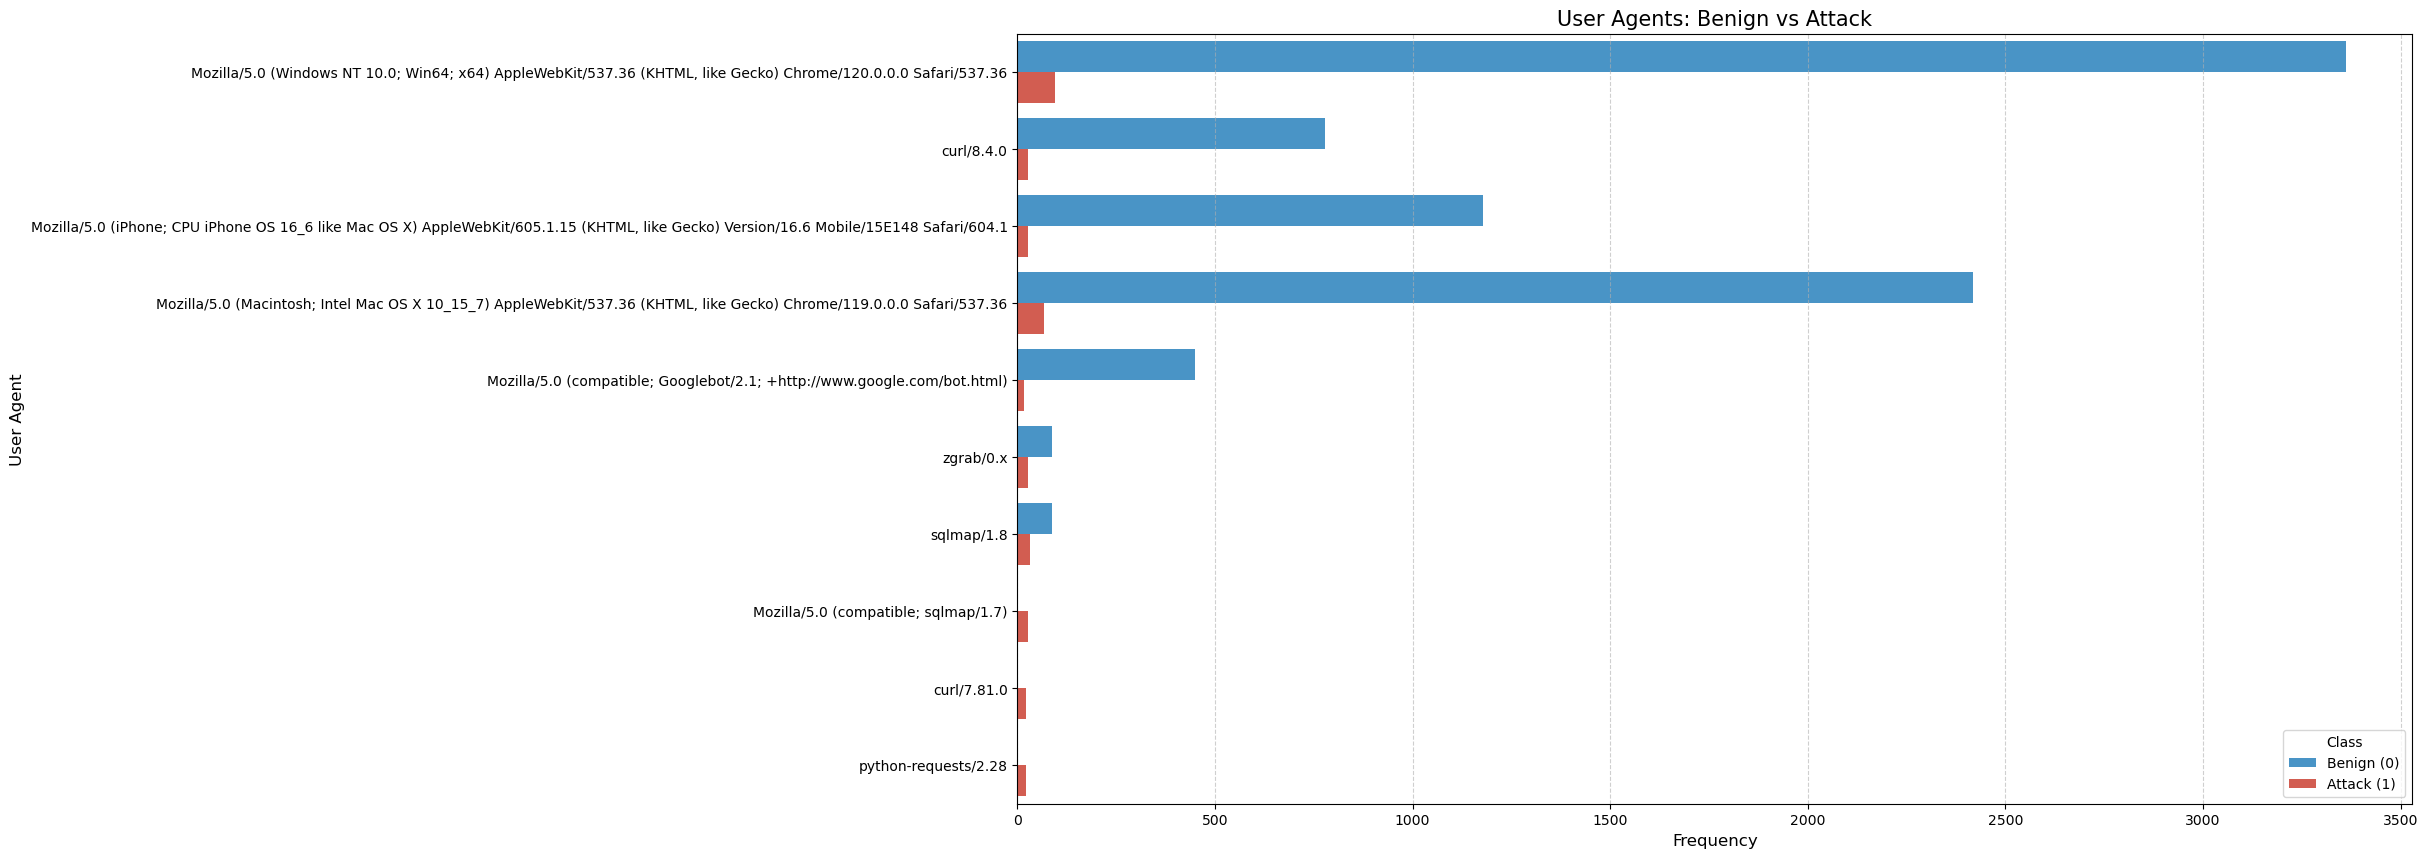

In [185]:
top_attacks = df[df['label'] == 1]['user_agent'].value_counts().head(10).index
df_comp = df[df['user_agent'].isin(top_attacks)]

plt.figure(figsize=(18, 10))
ax = sns.countplot(data=df_comp, y='user_agent', hue='label', palette={0: '#3498db', 1: '#e74c3c'})

plt.title('User Agents: Benign vs Attack', fontsize=15)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('User Agent', fontsize=12)
plt.legend(title='Class', labels=['Benign (0)', 'Attack (1)'])
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

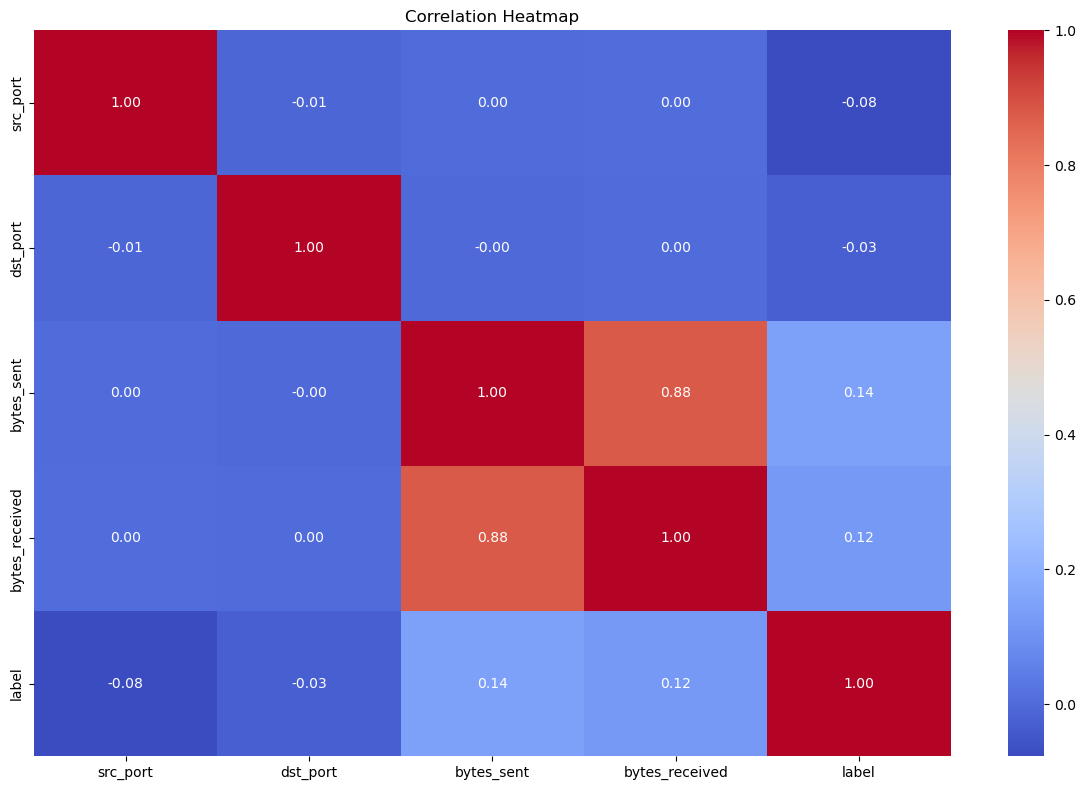

In [186]:
# Correlation heatmap
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
#plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

#### Feature engineering

In [187]:
#Create different columns based on the time stamp column
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df['is_weekend'] = df['timestamp'].dt.dayofweek.isin([5, 6]).astype(int)
df.drop(columns=['timestamp'], inplace=True)

In [188]:
df['log_bytes_sent'] = np.log1p(df['bytes_sent'])
df['log_bytes_received'] = np.log1p(df['bytes_received'])

In [189]:
#Port binning

bins = [-1, 1023, 49151, 65535]
labels = ['System', 'Registered', 'Dynamic']

df['dst_port_category'] = pd.cut(df['dst_port'], bins=bins, labels=labels)
df['src_port_category'] = pd.cut(df['src_port'], bins=bins, labels=labels)

In [190]:
df['user_agent'] = df['user_agent'].str.lower()

bot_agents = ['sqlmap', 'python', 'curl', 'zgrab']

df['riskAgent'] = df['user_agent'].apply(
    lambda x: 1 if any (pattern in x for pattern in bot_agents) else 0
)

In [191]:
df.drop(columns=['url', 'src_ip', 'dst_ip'], inplace=True)
print(df.shape)

(10000, 18)


In [192]:
# Binary encode is_internal_traffic
df['is_internal_traffic'] = df['is_internal_traffic'].astype(int)

print(df.dtypes)

src_port                  int64
dst_port                  int64
protocol                 object
bytes_sent                int64
bytes_received            int64
user_agent               object
is_internal_traffic       int64
label                     int64
attack_type              object
hour                      int32
day_of_week               int32
month                     int32
is_weekend                int64
log_bytes_sent          float64
log_bytes_received      float64
dst_port_category      category
src_port_category      category
riskAgent                 int64
dtype: object


In [193]:
df['label'] = (df['attack_type'] != 'benign').astype(int)
df.drop(columns=['attack_type'], inplace=True)
df.drop_duplicates(inplace=True)
print(df.shape)
print(df['label'].value_counts())

(10000, 17)
label
0    9600
1     400
Name: count, dtype: int64


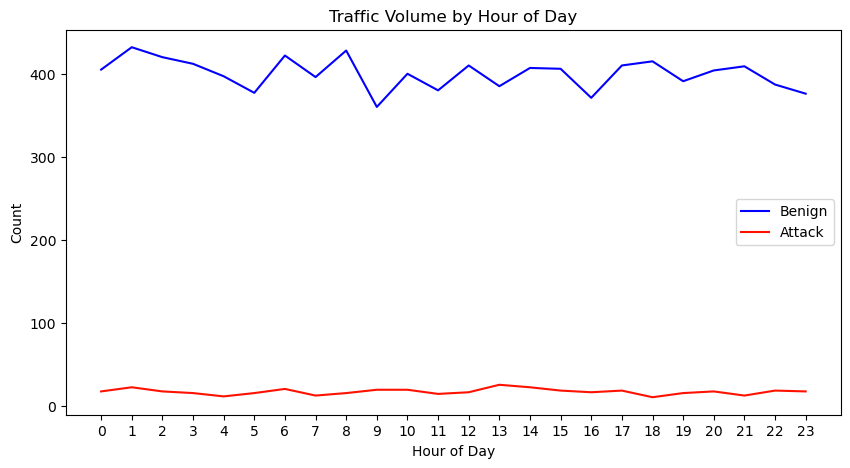

In [194]:
# NEW: Attacks by hour of day
hours = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23]
plt.figure(figsize=(10,5))
attack_by_hour = df[df['label']==1]['hour'].value_counts().sort_index()
benign_by_hour = df[df['label']==0]['hour'].value_counts().sort_index()
plt.plot(benign_by_hour.index, benign_by_hour.values, label='Benign', color="#0400FF")
plt.plot(attack_by_hour.index, attack_by_hour.values, label='Attack', color="#FF1100")
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.title('Traffic Volume by Hour of Day')
plt.xticks(hours)
plt.legend()
#plt.tight_layout()
#plt.savefig('hourly_traffic.png', dpi=150)
plt.show()

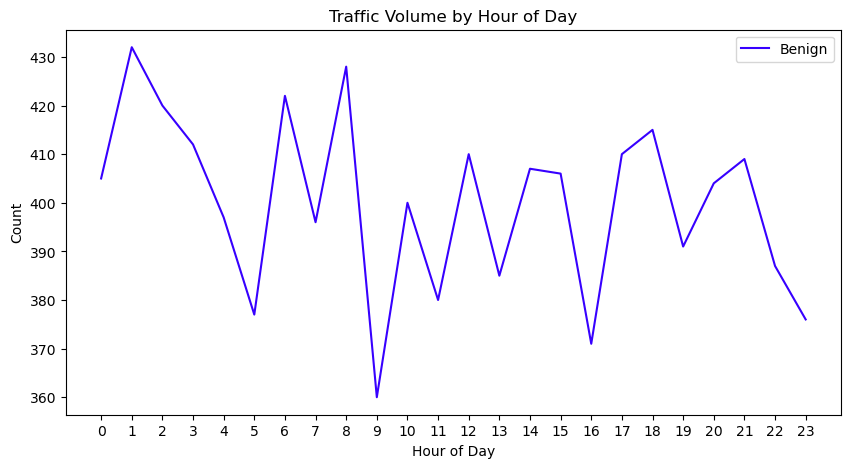

In [195]:
#Traffic volume (benign)
plt.figure(figsize=(10,5))
benign_by_hour = df[df['label']==0]['hour'].value_counts().sort_index()
plt.plot(benign_by_hour.index, benign_by_hour.values, label='Benign', color="#3700FF")
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.title('Traffic Volume by Hour of Day')
plt.xticks(hours)
plt.legend()
#plt.tight_layout()
#plt.savefig('hourly_traffic_attacks.png', dpi=150)
plt.show()

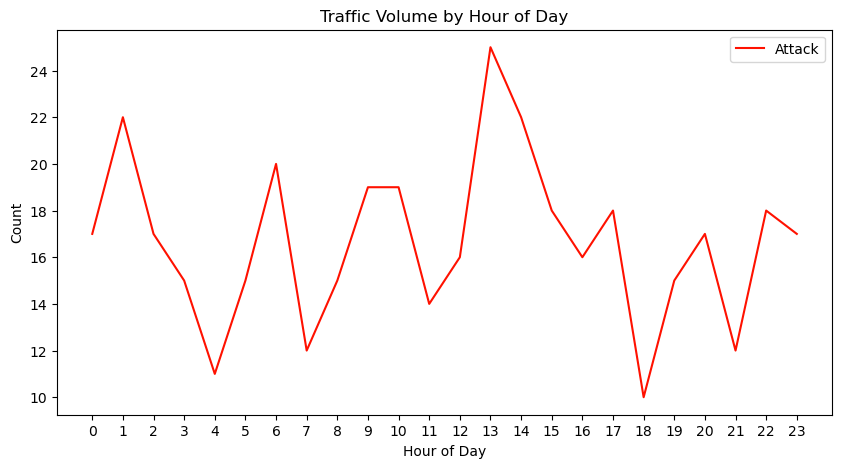

In [196]:
#Traffic volume (attack)
plt.figure(figsize=(10,5))
attack_by_hour = df[df['label']==1]['hour'].value_counts().sort_index()
plt.plot(attack_by_hour.index, attack_by_hour.values, label='Attack', color="#FF1100")
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.title('Traffic Volume by Hour of Day')
plt.xticks(hours)
plt.legend()
#plt.tight_layout()
#plt.savefig('hourly_traffic_attacks.png', dpi=150)
plt.show()

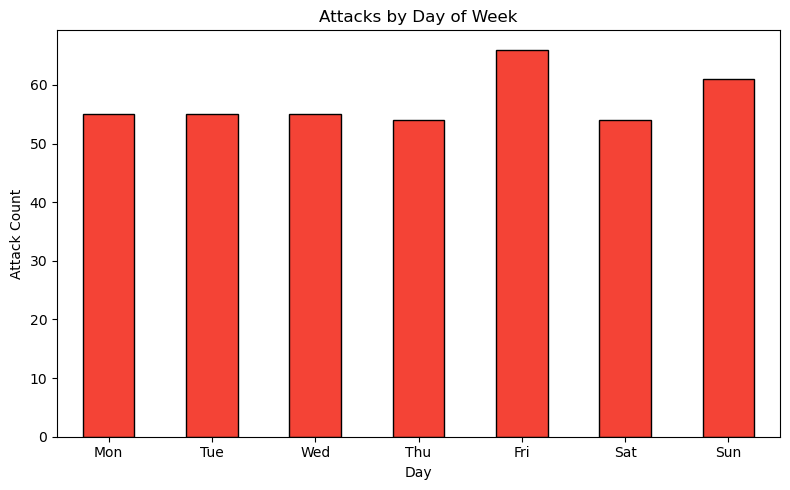

In [197]:
# NEW: Attacks by day of week
plt.figure(figsize=(8,5))
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
attack_by_day = df[df['label']==1]['day_of_week'].value_counts().sort_index()
attack_by_day.index = [days[i] for i in attack_by_day.index]
attack_by_day.plot(kind='bar', color='#F44336', edgecolor='black')
plt.title('Attacks by Day of Week')
plt.xlabel('Day')
plt.ylabel('Attack Count')
plt.xticks(rotation=0)
plt.tight_layout()
#plt.savefig('attacks_by_day.png', dpi=150)
plt.show()

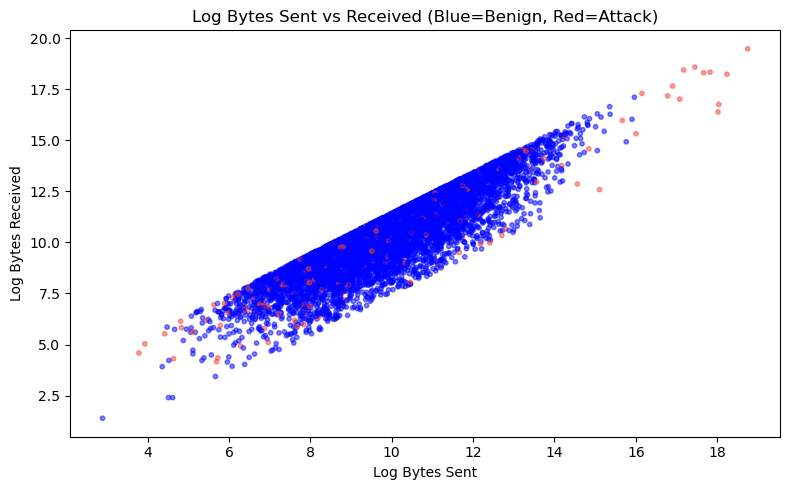

In [198]:
# Log bytes sent vs received scatter
plt.figure(figsize=(8,5))
colors = df['label'].map({0:"#0004FF", 1:'#F44336'})
plt.scatter(df['log_bytes_sent'], df['log_bytes_received'], c=colors, alpha=0.5, s=10)
plt.xlabel('Log Bytes Sent')
plt.ylabel('Log Bytes Received')
plt.title('Log Bytes Sent vs Received (Blue=Benign, Red=Attack)')
plt.tight_layout()
#plt.savefig('bytes_scatter.png', dpi=150)
plt.show()

/var/folders/yv/z_mmg1x11x3703_nbg6q2_9w0000gn/T/ipykernel_43095/817730400.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='dst_port_category', data=df, order=port_order, palette='viridis')


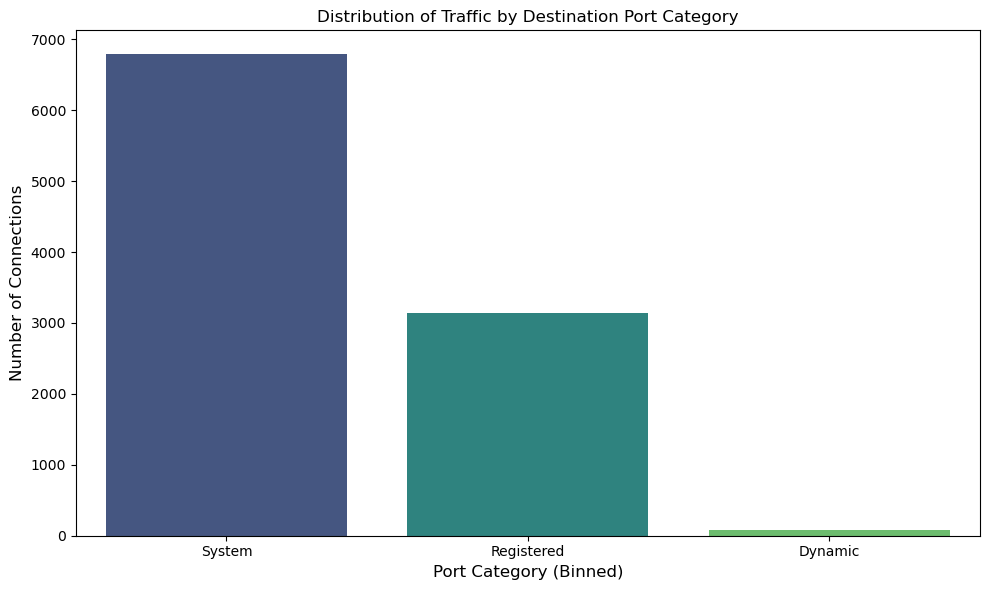

In [199]:
# Dst port binning
port_order = ['System', 'Registered', 'Dynamic']
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='dst_port_category', data=df, order=port_order, palette='viridis')
plt.title('Distribution of Traffic by Destination Port Category')
plt.xlabel('Port Category (Binned)', fontsize=12)
plt.ylabel('Number of Connections', fontsize=12)
plt.tight_layout()
# plt.savefig('port_binning_distribution.png', dpi=300, transparent=True)
plt.show()

/var/folders/yv/z_mmg1x11x3703_nbg6q2_9w0000gn/T/ipykernel_43095/2473691040.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='src_port_category', data=df, order=port_order, palette='viridis')


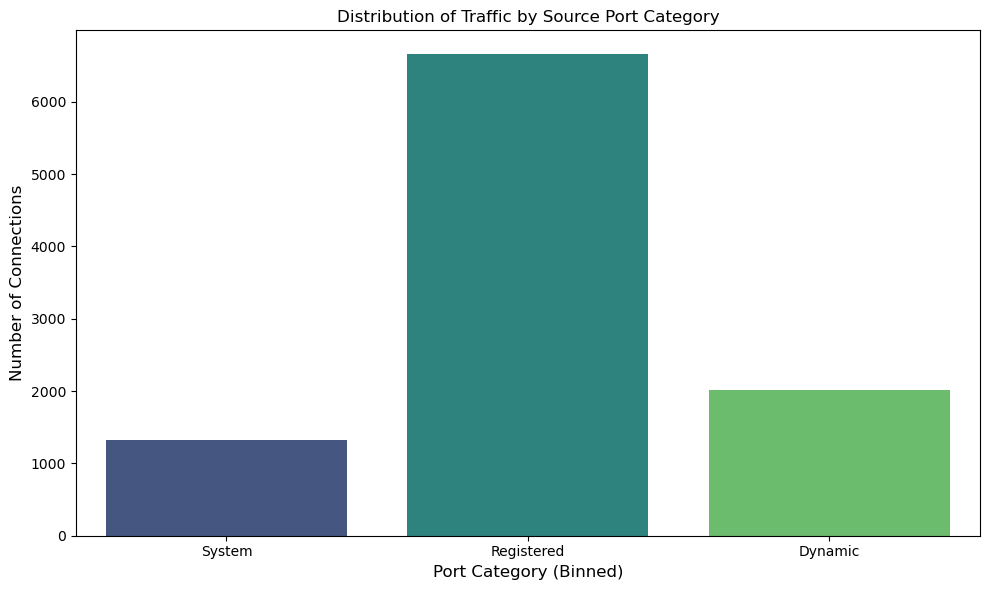

In [200]:
# Src port binning
port_order = ['System', 'Registered', 'Dynamic']
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='src_port_category', data=df, order=port_order, palette='viridis')
plt.title('Distribution of Traffic by Source Port Category')
plt.xlabel('Port Category (Binned)', fontsize=12)
plt.ylabel('Number of Connections', fontsize=12)
plt.tight_layout()
# plt.savefig('port_binning_distribution.png', dpi=300, transparent=True)
plt.show()

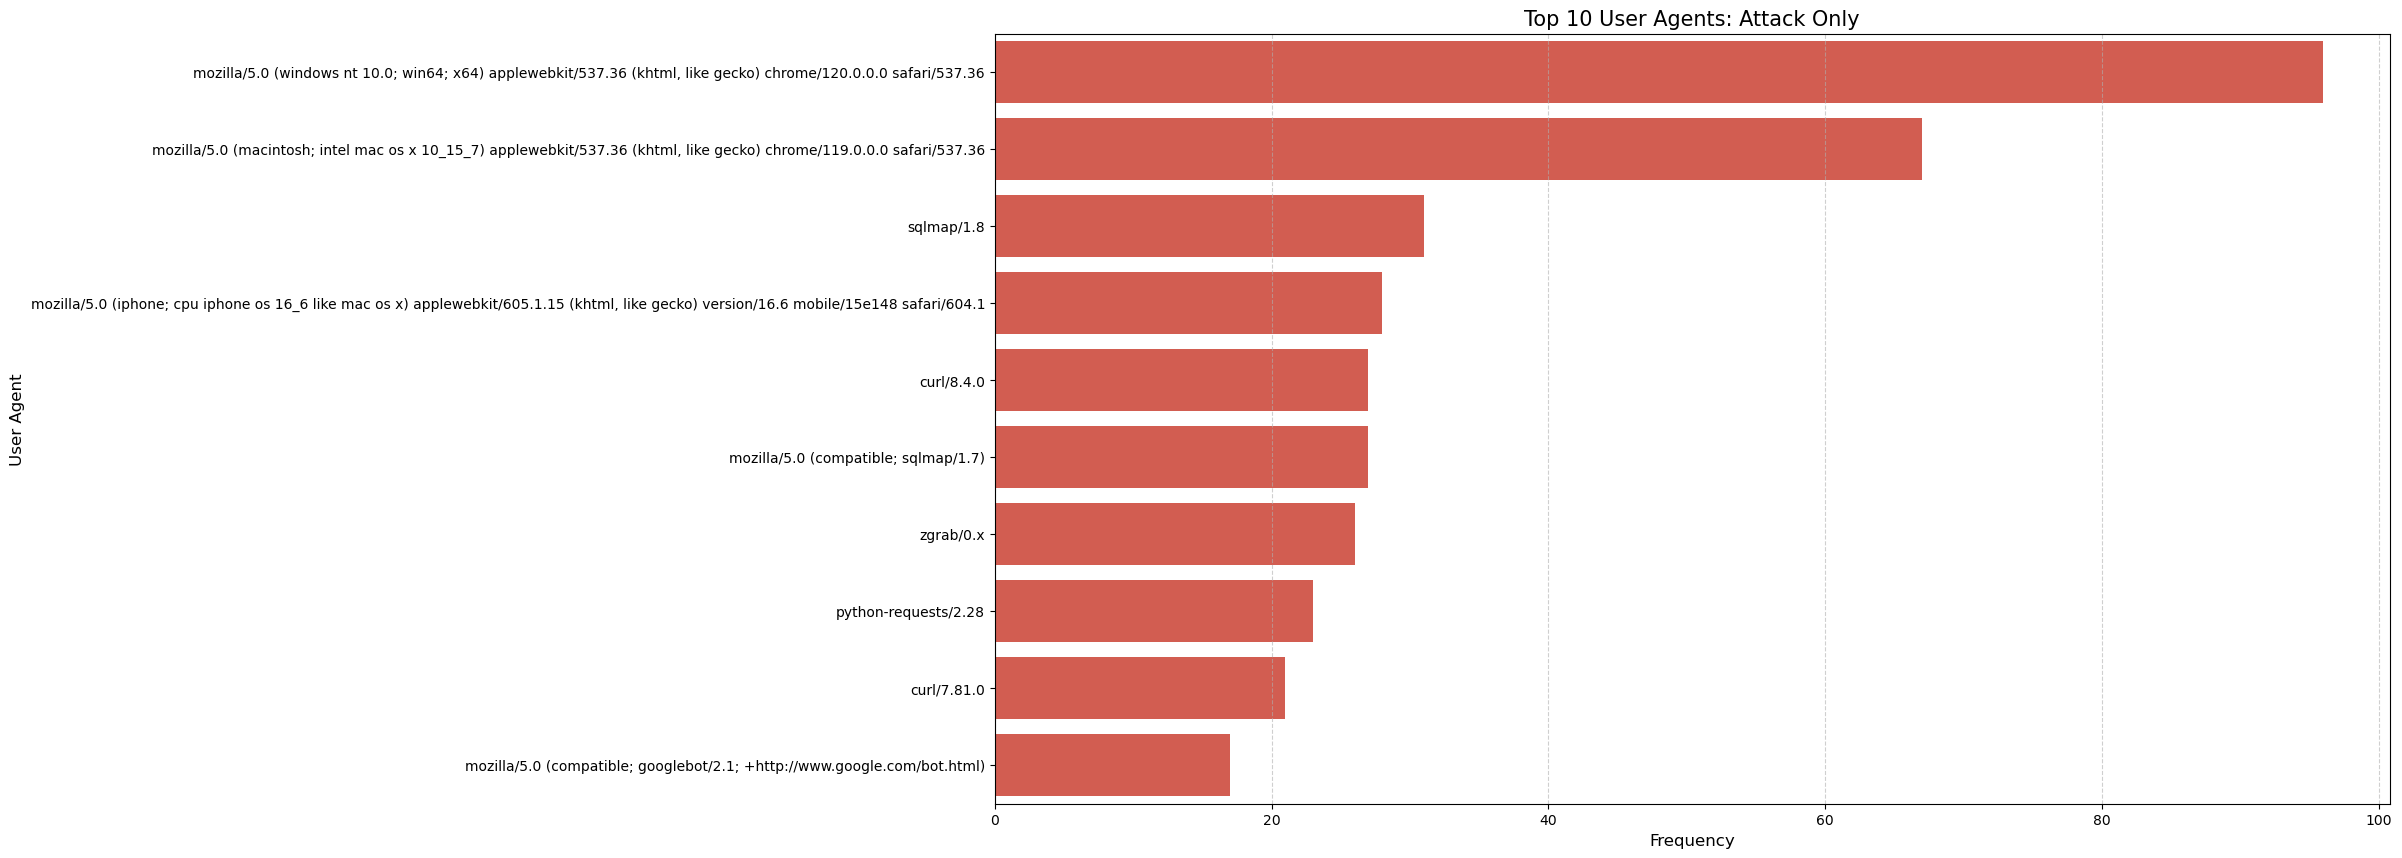

In [201]:

df_attacks = df[df['label'] == 1]

top_attacks_idx = df_attacks['user_agent'].value_counts().head(10).index
df_plot = df_attacks[df_attacks['user_agent'].isin(top_attacks_idx)]

plt.figure(figsize=(18, 10))
sns.countplot(data=df_plot, y='user_agent', color='#e74c3c', order=top_attacks_idx)

plt.title('Top 10 User Agents: Attack Only', fontsize=15)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('User Agent', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

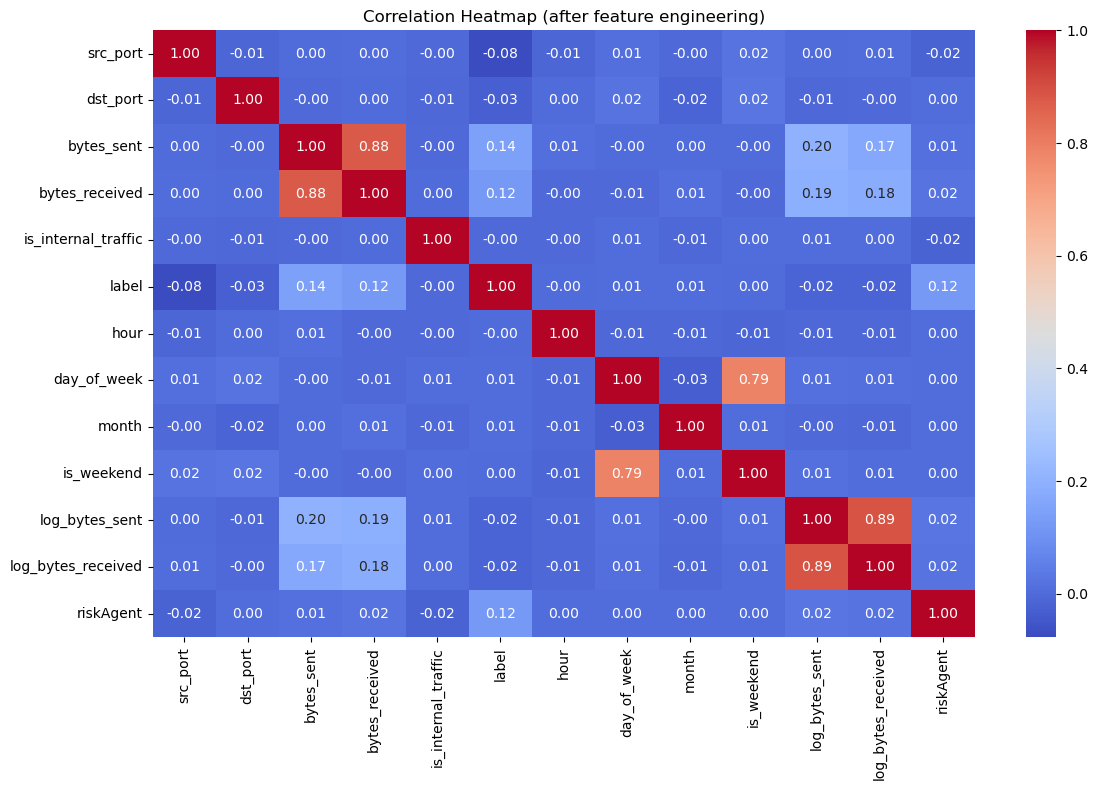

In [202]:
# Correlation heatmap after feature engineering
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap (after feature engineering)')
plt.tight_layout()
#plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [203]:
print(df.columns)

Index(['src_port', 'dst_port', 'protocol', 'bytes_sent', 'bytes_received',
       'user_agent', 'is_internal_traffic', 'label', 'hour', 'day_of_week',
       'month', 'is_weekend', 'log_bytes_sent', 'log_bytes_received',
       'dst_port_category', 'src_port_category', 'riskAgent'],
      dtype='object')


#### Logistic Regression

In [204]:
#Splitting data
X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [205]:
#Separate columns type
numerical_cols = X_train.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()

In [206]:
numeric_pipeline = Pipeline([
    ("scaler", StandardScaler()), #This is a placeholder
])

In [207]:
#Define cross validation with 5 splits
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [208]:
LR_preprocessor = ColumnTransformer(
    [
        ("num", numeric_pipeline, numerical_cols), #Scale
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols), #Encode
    ]
)

In [209]:
LR_Pipeline = Pipeline([
    ("preprocessing", LR_preprocessor),
    ("smote", SMOTE(random_state=42)), #Use SMOTE to balance data
    ("model", LogisticRegression(class_weight='balanced',max_iter=1000))
])

LR_grid = [
    {
        "preprocessing__num__scaler": [StandardScaler(), MinMaxScaler(), RobustScaler()],
        "model__C": [0.01, 0.1, 1, 10],
    }
]

In [210]:
GS_LogisticRegression = GridSearchCV(
    LR_Pipeline,
    LR_grid,
    cv = cv,
    scoring='f1',
    n_jobs=-1,
)

GS_LogisticRegression.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"[{'model__C': [0.01, 0.1, ...], 'preprocessing__num__scaler': [StandardScaler(), MinMaxScaler(), ...]}]"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [211]:
best_LR_params = GS_LogisticRegression.best_params_
print(best_LR_params)

{'model__C': 0.1, 'preprocessing__num__scaler': StandardScaler()}


In [212]:
best_f1_score = GS_LogisticRegression.best_score_
print(best_f1_score)

0.23034736265954397


In [213]:
y_pred_lr = GS_LogisticRegression.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.98      0.82      0.89      1920
           1       0.14      0.69      0.23        80

    accuracy                           0.81      2000
   macro avg       0.56      0.75      0.56      2000
weighted avg       0.95      0.81      0.87      2000



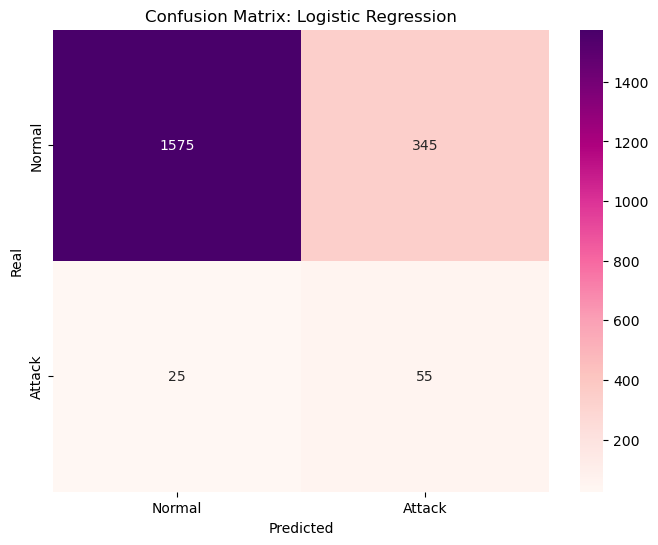

In [214]:
cm_log = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='RdPu', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'])

plt.title('Confusion Matrix: Logistic Regression')
plt.ylabel('Real')
plt.xlabel('Predicted')
plt.show()

#### Random Forest

In [215]:
RF_preprocessor = ColumnTransformer([
    ("num","passthrough", numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
]
)

RF_pipeline = Pipeline([
    ("preprocessing", RF_preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(class_weight='balanced',random_state=42))
])

In [216]:
RF_grid = [
    {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [8, 10, 20],
    "model__min_samples_split": [2, 5, 6],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", 0.5, 0.6],
    "model__class_weight": ["balanced"],
    "model__bootstrap": [True]
    }
]

In [217]:
RF_RandomForest = GridSearchCV(
    RF_pipeline,
    RF_grid,
    cv = cv,
    scoring='f1',
    n_jobs=-1,
)

RF_RandomForest.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'model__bootstrap': [True], 'model__class_weight': ['balanced'], 'model__max_depth': [8, 10, ...], 'model__max_features': ['sqrt', 0.5, ...], ...}]"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [218]:
best_RF_params = RF_RandomForest.best_params_
print(best_RF_params)

{'model__bootstrap': True, 'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__max_features': 0.5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 6, 'model__n_estimators': 200}


In [219]:
best_rf_f1_score = RF_RandomForest.best_score_
print(best_rf_f1_score)

0.5490021878314347


In [220]:
y_pred_rf = RF_RandomForest.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1920
           1       0.43      0.35      0.39        80

    accuracy                           0.96      2000
   macro avg       0.70      0.67      0.68      2000
weighted avg       0.95      0.96      0.95      2000



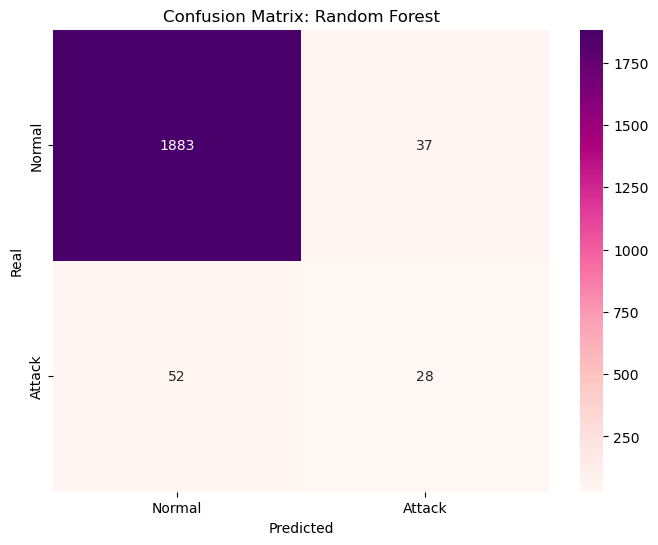

In [221]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='RdPu', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'])

plt.title('Confusion Matrix: Random Forest')
plt.ylabel('Real')
plt.xlabel('Predicted')
plt.show()

#### XGBoost

In [222]:
X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [223]:
XGB_preprocessor = ColumnTransformer(
    [
        ("num","passthrough", numerical_cols),#Passthrough ignores the scaling step
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

In [224]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() #Instead of using SMOTE

XGB_pipeline = Pipeline([
    ("preprocessing", XGB_preprocessor),
    ("model", XGBClassifier(
        n_estimators=500,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        random_state=42
    ))
])

In [225]:
XGB_grid = {
    "model__max_depth": [5, 6],
    "model__min_child_weight": [2, 3, 4],
    "model__gamma": [0, 0.1],
    "model__subsample": [1, 0.95, 0.9],
    "model__colsample_bytree": [0.6, 0.7],
    "model__learning_rate": [0.04, 0.05]
}

In [226]:
XGB_gridSearch = GridSearchCV(
    XGB_pipeline,
    XGB_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1
)

XGB_gridSearch.fit(X_train, y_train)

best_XGB_params = XGB_gridSearch.best_params_
print(best_XGB_params)
best_xgb_f1_score = XGB_gridSearch.best_score_
print('Best F1 ', best_xgb_f1_score)

{'model__colsample_bytree': 0.7, 'model__gamma': 0, 'model__learning_rate': 0.04, 'model__max_depth': 6, 'model__min_child_weight': 3, 'model__subsample': 1}
Best F1  0.6111567952818943


In [227]:
# BEST PARAMETERS (previous)

#{'model__colsample_bytree': 0.7, 'model__gamma': 0, 'model__learning_rate': 0.05, 'model__max_depth': 6, 'model__min_child_weight': 3, 'model__subsample': 0.9}

# NEW BEST PARAMS:
#{'model__colsample_bytree': 0.6, 'model__gamma': 0.1, 'model__learning_rate': 0.05, 'model__max_depth': 6, 'model__min_child_weight': 3, 'model__subsample': 1}

'''
{'model__colsample_bytree': 0.7, 'model__gamma': 0, 'model__learning_rate': 0.04, 'model__max_depth': 6, 'model__min_child_weight': 3, 'model__subsample': 1}
Best F1  0.6111567952818943
'''

"\n{'model__colsample_bytree': 0.7, 'model__gamma': 0, 'model__learning_rate': 0.04, 'model__max_depth': 6, 'model__min_child_weight': 3, 'model__subsample': 1}\nBest F1  0.6111567952818943\n"

In [228]:
#Find the best n_estimator and threshold, not the F1

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_thresholds = []
best_iterations = [] 

for train_idx, val_idx in kf.split(X_train, y_train):  
    
    model = XGBClassifier(   
        n_estimators=1500,
        early_stopping_rounds=50,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        **{k.replace("model__", ""): v for k, v in best_XGB_params.items()}
    )
    
    X_train_fold = X_train.iloc[train_idx]
    X_val_fold   = X_train.iloc[val_idx]
    y_train_fold = y_train.iloc[train_idx]
    y_val_fold   = y_train.iloc[val_idx]

    X_train_proc = XGB_preprocessor.fit_transform(X_train_fold)
    X_val_proc   = XGB_preprocessor.transform(X_val_fold)
    
    model.fit(
        X_train_proc,
        y_train_fold,
        eval_set=[(X_val_proc, y_val_fold)],
        verbose=False
    )

    best_iterations.append(model.best_iteration)

    y_probs = model.predict_proba(X_val_proc)[:, 1]

    best_f1 = 0
    best_t = 0
    for t in np.arange(0.1, 0.9, 0.01):
        y_pred = (y_probs >= t).astype(int)
        f1 = f1_score(y_val_fold, y_pred)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    best_thresholds.append(best_t)
    print(best_f1)

balanced_threshold = np.mean(best_thresholds)
final_n_estimators = int(np.mean(best_iterations)) + 1

print("Balanced Threshold:", balanced_threshold)
print("Final n_estimators:", final_n_estimators)

0.5864661654135338
0.6190476190476191
0.5794392523364486
0.6666666666666666
0.6451612903225806
Balanced Threshold: 0.5059999999999998
Final n_estimators: 833


In [229]:
final_model = XGBClassifier(
    n_estimators=final_n_estimators, #Use best n_estimators
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42,
    **{k.replace("model__", ""): v for k, v in best_XGB_params.items()} #Use best parameters
)

X_train_proc = XGB_preprocessor.fit_transform(X_train)
X_test_proc  = XGB_preprocessor.transform(X_test)

final_model.fit(X_train_proc, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'aucpr'


In [230]:
y_test_probs = final_model.predict_proba(X_test_proc)[:, 1]
y_test_pred = (y_test_probs >= balanced_threshold).astype(int) #Use the best threshold found
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1920
           1       0.67      0.60      0.63        80

    accuracy                           0.97      2000
   macro avg       0.83      0.79      0.81      2000
weighted avg       0.97      0.97      0.97      2000



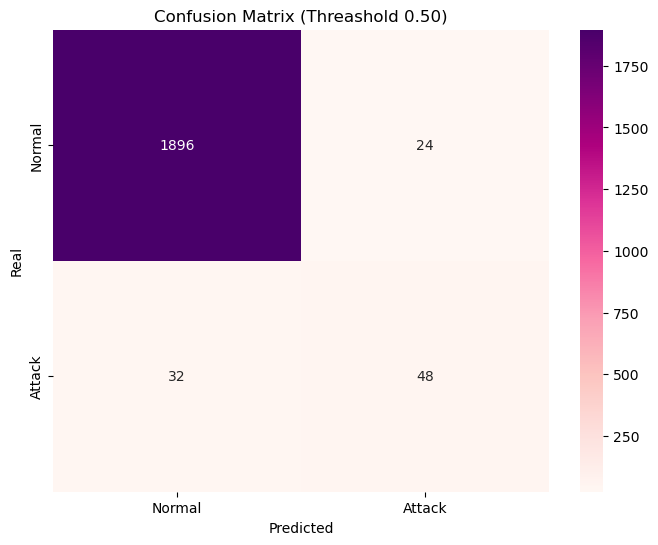

In [231]:
#Confusion Matrix
y_probs = final_model.predict_proba(X_test_proc)[:, 1]
y_pred_final = (y_probs >= balanced_threshold).astype(int) #Using best threashold

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix (Threashold 0.50)')
plt.ylabel('Real')
plt.xlabel('Predicted')
plt.show()

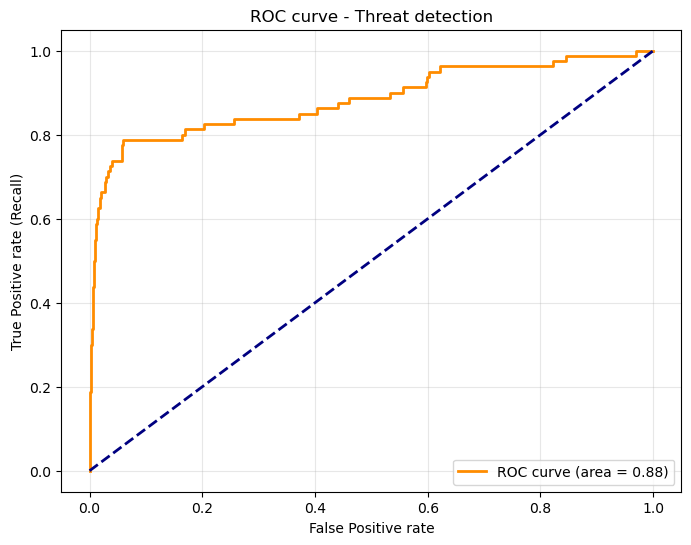

In [232]:
#ROC curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('ROC curve - Threat detection')
plt.xlabel('False Positive rate')
plt.ylabel('True Positive rate (Recall)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

/var/folders/yv/z_mmg1x11x3703_nbg6q2_9w0000gn/T/ipykernel_43095/1562227285.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


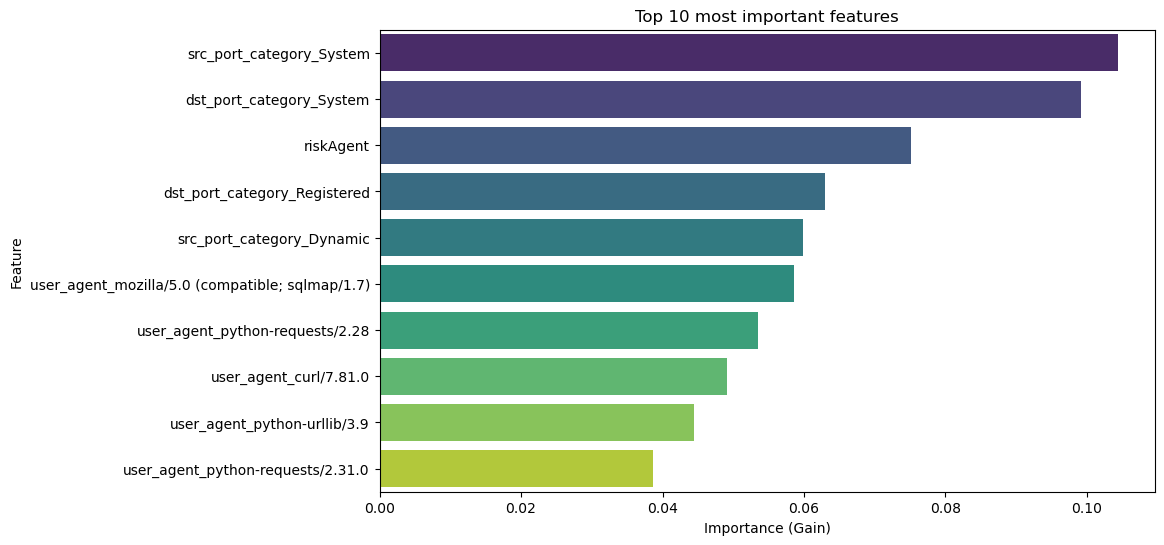

In [233]:
#Top 10 features
cat_encoder = XGB_preprocessor.named_transformers_['cat']
cat_features = list(cat_encoder.get_feature_names_out(categorical_cols))
all_features = numerical_cols + cat_features

importances = final_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(10), 
    palette='viridis'
)

plt.title('Top 10 most important features')
plt.xlabel('Importance (Gain)')
plt.show()

In [234]:
model_data = {
    "full_pipeline": final_model,
    "preprocessor": XGB_preprocessor,
    "threshold": balanced_threshold
}

with open('cyber_threat_model_vFinal.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("Model saved as: 'cyber_threat_model_vFinal.pkl' ")

Model saved as: 'cyber_threat_model_vFinal.pkl' 
